# 1. Introduction to Plotly

**Plotly** is a **graphing library** that allows you to create **interactive, publication-quality visualizations** directly from Python, R, Julia, or JavaScript.

At its core:

- **Built on Plotly.js** — a JavaScript visualization library that uses HTML, CSS, and SVG/WebGL for rendering.
- **Two main APIs in Python**:
  - **Plotly Express (`px`)** — high-level, concise syntax for rapid prototyping from pandas DataFrames.
  - **Graph Objects (`go`)** — low-level, fully customizable figures with granular control.
- **Integration**:
  - Works seamlessly in **Jupyter Notebooks/Lab**, VS Code, and many web frameworks (notably **Dash** for dashboards).
  - Figures are **self-contained HTML** — easy to share, embed, and export.

### Why Use Plotly?
- **Interactivity** built-in: hover tooltips, zoom, pan, legend toggling, and animations — without writing JavaScript.
- **Broad chart coverage**:
  - Statistical charts (scatter, bar, box, histogram, KDE, violin, etc.)
  - Time-series & financial charts
  - Geographic maps & choropleths
  - 3D surface and scatter plots
  - Network and Sankey diagrams
- **Customizable design**: Control colors, layouts, annotations, and styles in detail.
- **Cross-platform sharing**: Export to HTML for interactive sharing, or to PNG/SVG/PDF for print.

In short: Plotly bridges **data analysis** and **storytelling** — letting you go from a DataFrame to an interactive, shareable chart in just a few lines of Python.


# 2. Environment Setup
We’ll verify dependencies and set sensible defaults. If you do not have Plotly or pandas installed, use `pip` on the command line or the magic Notebook command `%pip`.


In [33]:
%pip install plotly nbformat


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

px.defaults.template = "plotly_white"
px.defaults.width = 800
px.defaults.height = 450


## 2.2. About Plotly’s Mental Model
- **Figure**: A container with one or more **traces** (data series) plus layout.
- **Trace**: Visual marks (e.g., scatter, bar, line). A trace maps data fields to channels (x, y, color, size, etc.).
- **Layout**: Global settings: axes, titles, annotations, legend, margins, templates.
- **Interactivity**: Hover, zoom, pan, selections, legend toggling are built-in.


# 3. First Steps with Plotly Express
Plotly Express (PX) is a concise, high-level API that builds a figure from a single call.


## 3.1. Load a Real Dataset
We’ll use Gapminder (country-year data for GDP, population, and life expectancy).


In [35]:
gap = px.data.gapminder()
gap.head()

,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


## 3.2. First Plot: Interactive Scatter
A classic: GDP per capita vs. life expectancy. We’ll map **color** to continent and **size** to population.

In [36]:
fig = px.scatter(
    gap.query("year == 2007"),
    x="gdpPercap", y="lifeExp",
    color="continent", size="pop",
    hover_name="country",
    log_x=True,
    title="3.2. GDP per Capita vs. Life Expectancy (2007)"
)
fig.show()

With Plotly, we have interactive capabilities built-in to the rendering, as it uses HTML, CSS, and JavaScript under the hood. We have hover tooltips, zooming, panning, and other rich interactive features available to us for free.

## 3.3. Improving Readability
We’ll refine bubble size, titles, axis labels, number formats, and legend position.


In [37]:
fig = px.scatter(
    gap.query("year == 2007"),
    x="gdpPercap", y="lifeExp",
    color="continent", size="pop",
    hover_name="country",
    # format the numerical fields nicely
    hover_data={"gdpPercap": ":,.0f", "pop": ":,d"},
    size_max=46, log_x=True,
    title="3.3. GDP vs. Life Expectancy (2007)"
)
fig.update_layout(
    xaxis_title="GDP per Capita (log scale)",
    yaxis_title="Life Expectancy (years)",
    legend_title_text="Continent",
    margin=dict(l=60, r=40, t=60, b=50)
)
fig.update_xaxes(ticks="outside", showline=True, linewidth=1)
fig.update_yaxes(ticks="outside", showline=True, linewidth=1)
fig.show()

## 3.4. Faceting (Small Multiples)
Faceting affords comparison by splitting the data into panels.


In [38]:
fig = px.scatter(
    gap.query("year == 2007"),
    x="gdpPercap", y="lifeExp",
    color="continent", facet_col="continent",
    facet_col_wrap=3, log_x=True, opacity=0.8,
    title="3.4. Small Multiples by Continent (2007)"
)
fig.for_each_annotation(lambda x: x.update(text=x.text.split("=")[-1]))
fig.update_layout(showlegend=True)
fig.show()


## 3.5. Animation Over Time
Plotly can animate year-over-year changes to support motion-based analysis.


In [39]:
fig = px.scatter(
    gap, x="gdpPercap", y="lifeExp",
    animation_frame="year", animation_group="country",
    size="pop", color="continent", hover_name="country",
    log_x=True, size_max=45, range_x=[200, 100000], range_y=[20, 90],
    title="3.5. Gapminder Animated: GDP vs Life Expectancy (1952–2007)"
)
fig.show()


# 4. Core Chart Types
We’ll quickly tour bar, line, histogram, box, and violin charts.



## 4.1. Line Charts (Time Series)


In [40]:
stocks = px.data.stocks()
# harmonize modern tickers
stocks = stocks.rename(columns={"GOOG": "GOOGL", "FB": "META"})
fig = px.line(
    stocks, x="date", y=["AAPL", "AMZN", "GOOGL", "MSFT", "META", "NFLX"],
    title="4.1. Tech Stocks"
)
fig.update_layout(legend_title_text="Ticker")
fig.show()


## 4.2. Bar Charts (Grouped & Stacked)


In [41]:
tips = px.data.tips()
fig = px.bar(
    tips, x="day", y="total_bill", color="sex",
    barmode="group", title="4.2. Grouped Bars: Total Bill by Day and Sex"
)
fig.show()

fig = px.bar(
    tips, x="day", y="total_bill", color="sex",
    barmode="relative", title="4.2. Stacked Bars: Total Bill by Day and Sex"
)
fig.show()

## 4.3. Histograms
Histograms show distributions; add `color` to compare subgroups.


In [42]:
fig = px.histogram(
    tips, x="total_bill", nbins=30, color="sex",
    title="4.3. Distribution of Total Bill (by Sex)"
)

fig.update_traces(opacity=0.75)
fig.show()

## 4.4 Box Plots

Here we plot a basic box plot with the same data to see further details about the statistics and outliers of the dataset.

In [43]:
fig = px.box(tips, x="day", y="total_bill", color="sex",
             title="4.4. Box Plot: Total Bill by Day and Sex")

fig.show()

## 4.5. Violin Plots and KDE

**Kernel Density Estimation (KDE)** is a **non-parametric** method for estimating a continuous probability density function (PDF) from data.  
Rather than binning observations (like a histogram), KDE places a smooth kernel (often Gaussian) at each data point and sums them to form a continuous curve.

**Formula:**
$$
\hat{f}(x) = \frac{1}{n\,h} \sum_{i=1}^n K\!\left( \frac{x - x_i}{h} \right)
$$

Where:  
- `n` = number of data points  
- `h` = bandwidth (smoothing parameter)  
- `K(•)` = kernel function (e.g., Gaussian, Epanechnikov)  

**Key idea:** The **bandwidth** determines how smooth the curve is:  
- Too small → noisy curve (overfitting)  
- Too large → oversmoothed (loss of detail)


At its core, KDE is answering this question:

_"If I believe my data comes from some unknown continuous distribution, what does that distribution look like?"_

It's an estimate of the underlying probability density function (PDF) — a smooth curve that says how likely different values are, based on your sample data.

Let's examine KDE in Matplotlib with Seaborn on a histogram:


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


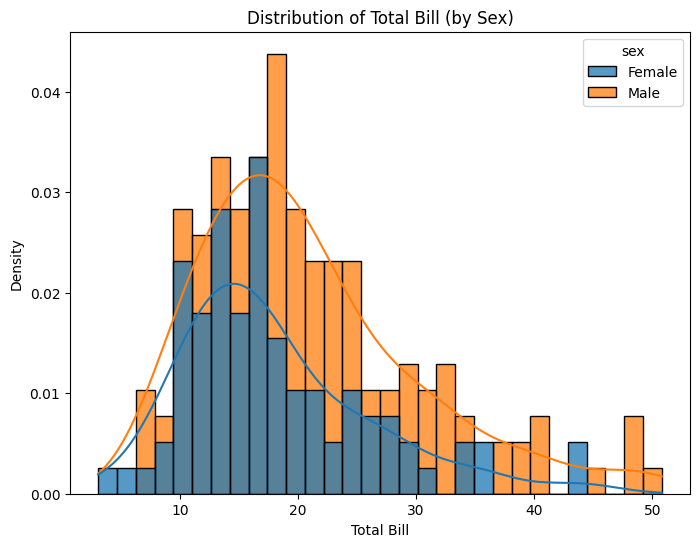

In [44]:
%pip install seaborn

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Get the same dataset from Plotly
tips = px.data.tips()

plt.figure(figsize=(8, 6))

sns.histplot(
    data=tips,
    x="total_bill",
    hue="sex",            # group by 'sex'
    bins=30,
    kde=True,             # add KDE curve
    stat="density",       # normalize to probability density
    alpha=0.75
)

plt.title("Distribution of Total Bill (by Sex)")
plt.xlabel("Total Bill")
plt.ylabel("Density")
plt.show()

A **violin** plot combines a box plot (median, quartiles, range) with a kernel density estimate (KDE) to show both summary statistics and the shape of the data distribution.

How to read:

- Width at a value → relative frequency.

- Narrow waist → fewer points.

- Wide bulge → more points.

- Line inside → median; box → interquartile range.

When to use:

- Comparing groups with different distribution shapes.

- Detecting skewness or multiple peaks.

In [45]:
fig = px.violin(tips, x="sex", y="total_bill", box=True, points="all",
                title="4.5. Violin Plot: Total Bill by Day and Sex")
fig.show()

For comparison, here's the histogram with KDE:

<img src="./histogram_kde.png" style="width:700px" />


# 5. Customization & Design Principles
We’ll align the visuals with design intent and theory.



## 5.1. Axes, Titles, Legends, and Margins


In [46]:
df = gap.query("year == 2007")
fig = px.scatter(
    df, x="gdpPercap", y="lifeExp", color="continent",
    hover_name="country", size="pop", log_x=True,
    title="5.1. Refining Layout Elements"
)
fig.update_layout(
    xaxis_title="GDP per Capita (log)",
    yaxis_title="Life Expectancy (years)",
    legend_title_text="Continent",
    margin=dict(l=60, r=40, t=60, b=50),
)
fig.update_xaxes(ticks="outside", showline=True, linewidth=1)
fig.update_yaxes(ticks="outside", showline=True, linewidth=1)
fig.show()

## 5.2. Tooltips and `hover_data` vs. `hovertemplate`
- `hover_data`: quick formatting and field inclusion/exclusion.
- `hovertemplate`: pixel-level control over tooltip text (advanced).


In [47]:
fig = px.scatter(
    df, x="gdpPercap", y="lifeExp", color="continent",
    hover_name="country",
    hover_data={"gdpPercap": ":,.0f", "lifeExp": ":.1f", "pop": ":,d"},
    log_x=True, title="5.2. Formatted Hover with hover_data"
)

fig.update_layout(xaxis_title="GDP per Capita (log)",
                  yaxis_title="Life Expectancy")
fig.show()

fig2 = px.scatter(df, x="gdpPercap", y="lifeExp", color="continent", log_x=True,
                  hover_name="country")

fig2.update_traces(
    hovertemplate=(
        "<b>%{hovertext}</b><br><br>"  # country from hover_name
        "GDP per Capita: %{x:,.0f}<br>"
        "Life Exp.: %{y:.1f} years<br>"
    )
)
fig2.update_layout(title="5.2. Custom Tooltip with hovertemplate",
                   xaxis_title="GDP per Capita (log)", yaxis_title="Life Expectancy")
fig2.show()

## 6. Bringing it all together

Let's combine all the parts we've learned into one visualization to rule them all:

In [48]:
fig = px.scatter(df, x="gdpPercap",
                 y="lifeExp", color="continent", size="pop", log_x=True,
                 size_max=50, symbol="continent",
                 hover_name="country")

fig.update_traces(
    hovertemplate=(
        "<b>%{hovertext}</b><br>"  # country from hover_name
        "GDP per Capita: %{x:,.0f}<br>"
        "Life Exp.: %{y:.1f} years<br>"
    )
)
fig.update_layout(title="6. Completed Visualization", xaxis_title="GDP per Capita (log)", yaxis_title="Life Expectancy", legend_title_text="Continent")
fig.show()